## Expected Credit Loss (ECL) Modeling for Retail Loans
## Notebook 1
## Project Overview, Dataset overview
## Data Import, Cleaning, 

---


## Author: Will Wu

## Date: 2025-11-14
---

## **Table of Contents** ##

1. [Project Overview](#1)
2. [Data Dictionary](#2)
3. [Setup and Loading](#3)
4. [Data Cleaning](#4)
    - [Date Conversion and Temporal Ordering](#4a)
    - [Data Filtering](#4b)
    - [High Cardinality Features](#4c)
    - [Missing Values](#4d)
    - [Duplicated Data](#4e)
    - [Invalid Values](#4f)
    - [Value Type Transformation](#4g)
    - [Target Variable Creation](#4h)
5. [Summary and Export](#5)


---

## 1. Project Overview <a class="anchor" id="1"></a>

### Why Banks Need to Predict Expected Credit Loss (ECL)

Banks and lending institutions face the fundamental challenge of managing credit risk to ensure financial stability, regulatory compliance, and profitability. Accurate prediction of **Expected Credit Loss (ECL)** is essential because it provides a forward-looking estimate of potential losses from the loan portfolio. This estimation helps:

- Allocate sufficient capital reserves to cover anticipated losses.
- Price loans appropriately, balancing profitability with risk mitigation.
- Comply with regulatory standards such as IFRS 9 and Basel III, which require recognition of expected losses based on current and forecasted information.
- Establish and adjust credit policies to accommodate evolving borrower behavior and economic conditions.
- Monitor portfolio health continuously and adopt proactive risk management strategies to prevent unexpected losses.

### Definitions for Expected Credit Loss (ECL)

1. **Expected Credit Loss (ECL)**  
   - ECL is the primary metric for credit provisioning under accounting standards like IFRS 9. It represents the expected loss on a financial asset over a specific time horizon.  
    $$\text{ECL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

2. **Probability of Default (PD)**  
   - PD is the likelihood that a borrower will default over a particular period.  
   - Formula: $$\text{PD} = \frac{\text{Number of Defaults}}{\text{Total Loans on the Book}}$$ 
   - Modeled using Logistic Regression or machine learning techniques with a binary outcome.

3. **Loss Given Default (LGD)**  
   - LGD measures the severity of loss expected, expressed as a percentage of exposure, assuming default occurs.  
   - Formula: $$\text{LGD} = 1 - \text{Recovery Rate (RR)}  = 1 - \frac{\text{Total Recoveries (Net of Costs)}}{\text{Exposure at Default (EAD)}}$$
   - Modeled using Regression techniques such as Beta Regression, with IFRS 9 requiring cash flows to be discounted back to the date of default.

4. **Exposure At Default (EAD)**  
   - EAD is the total amount the bank is exposed to at the default event.  
   - For installment loans, EAD is often the Outstanding Principal Balance.  
   - For revolving credit, EAD includes calculations using the Credit Conversion Factor (CCF).  
   $$\text{EAD} = \text{Drawn Amount} + (\text{Undrawn Commitment} \times \text{CCF})$$ where $$\text{CCF} = \frac{\text{Amount Drawn at Default} - \text{Amount Drawn at Observation}}{\text{Total Undrawn Commitment at Observation}}$$
   - Due to the difficulty in obtaining accurate Amount Drawn at Default data, CCF modeling is not feasible. Therefore, EAD modeling will not be the focus of this project.

### Dataset Overview

The dataset used in this analysis is from Lending Club, a prominent peer-to-peer lending platform. Lending Club's data includes detailed information at the individual loan level, comprising features such as borrower demographics, credit scores, loan characteristics, and loan performance indicators. Specifically, it captures data points like:

- **Loan information:** loan status, loan amount, terms, interest rate, loan purpose
- **Borrower characteristics:** borrower_id, FICO score, income, employment length, zipcode
- **Performance variables:** payment status, month on book, outstanding balance, revolving balance, Debt-to-Income ratio
- **Derived features:** loan_age, utilization rate

This data closely resembles the type of data banks handle for credit risk models. The granular, loan-level details enable modeling of key risk components—PD, LGD, and EAD—which are critical for estimating **Expected Loss (EL)**.

### Goal of the Analysis

The primary objective is to **mimic how credit risk modelers at financial institutions develop models**—specifically, models for **Probability of Default (PD)**, **Loss Given Default (LGD)**, and **Exposure at Default (EAD)**—to predict **Expected Loss (EL)**. 

Even though the dataset lacks macroeconomic variables or forward-looking indicators, estimating PD, LGD, and EAD at the loan application level provides valuable insights:

- **PD modeling** assesses the likelihood of borrower default based on features available at application.
- **LGD modeling** estimates potential loss given default rate/(1 - recovery rate) in case of default.
- **EAD modeling** forecasts the outstanding exposure at the time of default.

By robustly modeling these components, the analysis can produce reliable estimates of EL, informing credit decision-making, supporting risk management strategies, and optimizing overall portfolio performance. This approach reflects practices from the industry and serves as a strong foundation for further enhancements, such as integrating macroeconomic data for more dynamic, forward-looking predictions.


### Limitations

1. Static Nature of Prediction (Snapshot Model):
<br>Due to the lack of a true time-varying data that captures borrower and economic data evolution post-issuance, the Probability of Default ($\text{PD}$) and Loss Given Default ($\text{LGD}$) models are static snapshot predictions. We are predicting the borrower's risk at the moment of loan issuance, not tracking the dynamic risk of the loan portfolio over its life (which would require a survival analysis or conditional $\text{PD}$ model).

2. Simplified Exposure at Default ($\text{EAD}$):
<br>Due to the lack of relevan data, this project does not model the Credit Conversion Factor ($\text{CCF}$), which is essential in real-world banking for revolving credit lines where borrowers often draw down available credit upon default. $\text{EAD}$ calculation is simplified to the remaining outstanding principal balance at the time of default, omitting the predictive challenge of estimating future drawdowns.


---

## 2. Data Dictionary <a class="anchor" id="2"></a>


| Column                     | Description                                                                                                              |
|----------------------------|--------------------------------------------------------------------------------------------------------------------------|
| addr_state                 | The state provided by the borrower in the loan application.                                                             |
| annual_inc                 | The self-reported annual income provided by the borrower during registration.                                             |
| annual_inc_joint           | The combined self-reported annual income provided by the co-borrowers during registration.                              |
| application_type           | Indicates whether the loan is an individual or joint application with two co-borrowers.                                |
| collection_recovery_fee    | Post charge-off collection fee.                                                                                          |
| collections_12_mths_ex_med | Number of collections in the past 12 months (excluding medical collections).                                          |
| delinq_2yrs                | Number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years.             |
| desc                       | Loan description provided by the borrower.                                                                               |
| dti                        | Debt-to-income ratio; the ratio of borrower’s total monthly debt payments to their monthly income.                     |
| dti_joint                  | DTI for co-borrowers, calculated similarly.                                                                             |
| earliest_cr_line           | The month the borrower's earliest reported credit line was opened.                                                     |
| emp_length                 | Employment length in years, from less than 1 year to 10+ years.                                                        |
| emp_title                  | Job title supplied by the borrower when applying for the loan.                                                           |
| fico_range_high            | Upper boundary of the borrower’s FICO score at loan origination.                                                        |
| fico_range_low             | Lower boundary of the borrower’s FICO score at loan origination.                                                        |
| funded_amnt                | Total amount funded to the loan at that point in time.                                                                 |
| funded_amnt_inv            | Total amount committed by investors for the loan at that point in time.                                                 |
| grade                      | LC assigned loan grade (e.g., A, B, C).                                                                                 |
| home_ownership             | Borrower’s home ownership status (RENT, OWN, MORTGAGE, OTHER).                                                          |
| id                         | Unique LC assigned ID for the loan listing.                                                                               |
| initial_list_status        | Initial status of the loan listing (e.g., W, F).                                                                        |
| inq_last_6mths             | Number of credit inquiries in the last 6 months (excluding auto and mortgage inquiries).                            |
| installment                | Monthly payment owed by the borrower if the loan originates.                                                          |
| int_rate                   | Interest rate on the loan.                                                                                                |
| is_inc_v                  | Whether income was verified by LC (Yes/No).                                                                              |
| issue_d                    | Month when the loan was funded.                                                                                            |
| last_credit_pull_d        | Most recent month LC pulled credit for this loan.                                                                        |
| last_fico_range_high      | Highest FICO score in the last pull.                                                                                        |
| last_fico_range_low       | Lowest FICO score in the last pull.                                                                                         |
| last_pymnt_amnt           | Last payment amount received.                                                                                              |
| last_pymnt_d              | Last month a payment was received.                                                                                          |
| loan_amnt                 | Total amount applied for by the borrower.                                                                                 |
| loan_status               | Current status of the loan (e.g., Fully Paid, Charged Off).                                                             |
| member_id                 | Unique LC ID for the borrower.                                                                                                |
| mths_since_last_delinq  | Months since the last delinquency.                                                                                          |
| mths_since_last_major_derog | Months since most recent major derogatory rating (90 days or worse).                                                    |
| mths_since_last_record   | Months since the last public record.                                                                                        |
| next_pymnt_d              | Next scheduled payment date.                                                                                               |
| open_acc                  | Number of open credit lines.                                                                                                |
| out_prncp                 | Remaining outstanding principal for total amount funded.                                                                |
| out_prncp_inv             | Remaining outstanding principal for portion funded by investors.                                                         |
| policy_code               | Policy code indicating public (1) or non-public (2) policy.                                                             |
| pub_rec                   | Number of derogatory public records.                                                                                        |
| purpose                   | Borrower's stated purpose of the loan.                                                                                      |
| pymnt_plan                | Whether a payment plan has been put in place.                                                                               |
| recoveries                | Post charge-off gross recovery amount.                                                                                     |
| revol_bal                 | Total revolving credit balance.                                                                                             |
| revol_util                | Revolving line utilization rate (balance / limit).                                                                        |
| sub_grade                 | Loan sub-grade assigned by LC (e.g., B2).                                                                                    |
| term                      | Number of payments (months) (36 or 60).                                                                                     |
| title                     | Loan title provided by the borrower.                                                                                         |
| total_acc                  | Total number of credit lines currently in the borrower's credit report.                              |
| total_pymnt                | Total payments received to date for the loan.                                                          |
| total_rec_prncp            | Total principal received to date.                                                                       |
| total_rec_int              | Total interest received to date.                                                                        |
| total_rec_late_fee         | Total late fees received to date.                                                                         |
| total_rec_prncp            | Total principal received to date (duplicate; same as above).                                            |
| url                        | URL for the Lending Club page with listing data.                                                        |
| verified_status_joint    | Whether the joint income was verified by LC, if applicable.                                              |
| zip_code                   | First 3 digits of the borrower's zip code.                                                              |
| open_acc_6m                | Number of open trades in the last 6 months.                                                               |
| open_il_6m                 | Number of active installment trades in the last 6 months.                                                 |
| open_il_12m                | Number of installment accounts opened in past 12 months.                                                   |
| open_il_24m                | Number of installment accounts opened in past 24 months.                                                   |
| mths_since_rcnt_il         | Months since most recent installment account was opened.                                                    |
| total_bal_il               | Total current balance of all installment accounts.                                                          |
| il_util                    | Ratio of total current balance to high credit/credit limit on all installment accounts.                  |
| open_rv_12m                | Number of revolving trades opened in the past 12 months.                                                   |
| open_rv_24m                | Number of revolving trades opened in the past 24 months.                                                   |
| max_bal_bc                 | Maximum current balance owed across all revolving accounts.                                                |
| all_util                   | Balance-to-credit-limit ratio across all trades.                                                           |
| total_rev_hi_lim           | Total high credit/credit limit on revolving accounts.                                                     |
|inq_fi                     | Number of personal finance inquiries.                                                                      |
| total_cu_tl                | Total number of finance trades (e.g., credit union trades).                                                  |
|inq_last_12m               | Number of credit inquiries in the past 12 months.                                                          |
| acc_now_delinq            | Number of accounts currently delinquent.                                                                   |
| tot_coll_amt               | Total collection amounts ever owed.                                                                        |
| tot_cur_bal                | Total current balance of all accounts.                                                                     |

---

## 3. Setup and Loading<a class="anchor" id="3"></a>

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Display options
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)

# Set the style
sns.set(style="whitegrid")

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [66]:
# Load the dataset
loan_df_raw = pd.read_csv("../data/loan_data_2007_2014.csv", index_col=0)

In [67]:
# Check the head
loan_df_raw.head().T

,0,1,2,3,4
id,1077501,1077430,1077175,1076863,1075358
member_id,1296599,1314167,1313524,1277178,1311748
loan_amnt,5000,2500,2400,10000,3000
funded_amnt,5000,2500,2400,10000,3000
funded_amnt_inv,4975.0000,2500.0000,2400.0000,10000.0000,3000.0000
term,36 months,60 months,36 months,36 months,60 months
int_rate,10.6500,15.2700,15.9600,13.4900,12.6900
installment,162.8700,59.8300,84.3300,339.3100,67.7900
grade,B,C,C,C,B
sub_grade,B2,C4,C5,C1,B5


In [68]:
# Check the tail
loan_df_raw.tail().T

,466280,466281,466282,466283,466284
id,8598660,9684700,9584776,9604874,9199665
member_id,1440975,11536848,11436914,11457002,11061576
loan_amnt,18400,22000,20700,2000,10000
funded_amnt,18400,22000,20700,2000,10000
funded_amnt_inv,18400.0000,22000.0000,20700.0000,2000.0000,9975.0000
term,60 months,60 months,60 months,36 months,36 months
int_rate,14.4700,19.9700,16.9900,7.9000,19.2000
installment,432.6400,582.5000,514.3400,62.5900,367.5800
grade,C,D,D,A,D
sub_grade,C2,D5,D1,A4,D3


In [69]:
# Check the shape of the df
print(f'Shape of the DataFrame: {loan_df_raw.shape}')

Shape of the DataFrame: (466285, 74)


---

## 4. Data Cleaning <a class="anchor" id="4"></a>


### 4.1 Date Conversion and Temporal Ordering <a class="anchor" id="4a"></a>

First, I need to sort the observations by their issue_date, represented in the `issue_d` column. This is important because credit risks evolve over time alongside macroeconomic factors. Sorting the data ensures that the temporal order is maintained. When performing train-test splits later, we should use rolling window split instead of random splits to better simulate real-world forecasting scenarios.

In [70]:
# Create a copy of raw dataset
loan_df_clean = loan_df_raw.copy()

In [71]:
# 1. Convert the 'issue_d' column to datetime 
loan_df_clean['issue_d'] = pd.to_datetime(loan_df_clean['issue_d'], format='%b-%y')
loan_df_clean['issue_d'].head(5)

0   2011-12-01
1   2011-12-01
2   2011-12-01
3   2011-12-01
4   2011-12-01
Name: issue_d, dtype: datetime64[ns]

In [72]:
# Sort the DataFrame chronologically by the new date column
loan_df_clean = loan_df_clean.sort_values(by='issue_d').reset_index(drop=True)

In [73]:
loan_df_clean.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m',
  

---

### 4.2 Data Filtering <a class="anchor" id="4b"></a>

The goal of this project is to accurately predict key credit risk metrics such as Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD). The original dataset contains over 70 features, which could lead to overfitting and hinder interpretability. 
<br>I watched an insightful [YouTube video](https://www.youtube.com/watch?v=881Q_bRpsj4&list=PLn699ZSeIUYeev-Fwyt-NLf7e5yKnY28q&index=7) that highlights the most informative features for credit risk modeling. To improve model performance, I will drop variables that are either redundant, irrelavant, low variance, and high cardinality. This helps me enhance interpretability, reduce overfitting, and build more efficient models.

| Feature                        | Reason for Exclusion                                              |
|--------------------------------|------------------------------------------------------------------|
| url                            | Not useful for modeling; contains URL links, irrelevant for analysis |
| desc                           | Text description, not useful for predictive modeling            |
| next_pymnt_d                   | Future payment date, unavailable or irrelevant for initial modeling |
| last_pymnt_d                   | Last payment date, may not contribute meaningfully               |
| last_credit_pull_d             | Last credit pull date, not predictive of current risk           |
| id                             | Unique identifier, non-informative for modeling                 |
| member_id                      | Unique customer identifier, does not influence risk factors     |
| earliest_cr_line               | Date feature with limited predictive value or redundant        |
| funded_amnt_inv                | Redundant with funded amount; relates to investment, not borrower risk |
| total_pymnt_inv                | Similar to above; not directly useful for PD or LGD modeling    |
| out_prncp_inv                  | Investment-related principal payments, less relevant for credit risk |
| application_type               | Redundant, e.g., individual vs joint lending, less predictive  |
| zip_code                       | Too granular, may cause overfitting; reduces model generalizability |
| pymnt_plan                     | Low variance, not useful; indicates plan type with little variation |
| policy_code                    | Low variance, non-informative, and mainly administrative        |
| tot_coll_amt                   | Reduntant, as totally collection amount can be reflected by total_rec_pmcp + total_rec_int        |
| collections_12_mths_ex_med                   | Number of times in recovery collection is less irrelavant compared to recovery collection amount and fees. This data might be leaky in indicating default        |
| acc_now_delinq                   |  Number of delinquent accounts might be leaky in implying delinquent and default status. I have already incorporated delinquent data.      |

In [74]:
# List of selected features for modeling
features_to_remove = [
     # unuseful data for PD LGD EAD
     'url', 'desc', 'next_pymnt_d', 'last_pymnt_d', 'last_credit_pull_d', 'id', 'member_id', 'earliest_cr_line',

    # redundant information
    'funded_amnt_inv', 'total_pymnt_inv', 'out_prncp_inv',  'application_type', 'zip_code', 'tot_coll_amt',

    # Low variance columns                 
     'pymnt_plan', 'policy_code',  

     # irrelavant and leaky
     'collections_12_mths_ex_med', 'acc_now_delinq'  
   
]

print(f"The total number of filtered features: {len(features_to_remove)}")

The total number of filtered features: 18


In [75]:
# Create a new df to store the selected data
loan_df_clean = loan_df_clean.drop(columns=features_to_remove)

In [76]:
# Sanity Check
loan_df_clean.shape

(466285, 56)

---

### 4.3 High cardinality features <a class="anchor" id="4c"></a>

High-cardinality categorical features should be dropped because they introduce instability and overfitting. Since these features act like identifiers, they complicate standard modeling techniques like Logistic Regression, undermine prediction reliability,

In [77]:
high_cardinality_cols = []

#  Get a list of categorical columns (dtype 'object')
categorical_cols = loan_df_clean.select_dtypes(include=['object']).columns


for col in categorical_cols:

    # Get the unique count
    unique_count = loan_df_clean[col].nunique()

    if unique_count > 1000:
        high_cardinality_cols.append({
            "Feature" : col,
            "Unique Values": unique_count
        })

In [78]:
# Show the results
pd.DataFrame(high_cardinality_cols)

,Feature,Unique Values
0,emp_title,205475
1,title,63098


In [79]:
# Check some data
loan_df_clean[['emp_title','title', 'purpose', 'loan_status']].head().T

,0,1,2,3,4
emp_title,"Stanford University Libraries, LOCKSS Project",Evergreen Center,Yale University,Brick Township board of education,Classic Components
title,Starting a new job in a new city,Consolidation Loan,Debt consolidation,VISA,College Debt Consolidation
purpose,other,debt_consolidation,debt_consolidation,debt_consolidation,other
loan_status,Does not meet the credit policy. Status:Fully ...,Fully Paid,Does not meet the credit policy. Status:Fully ...,Does not meet the credit policy. Status:Fully ...,Does not meet the credit policy. Status:Fully ...


`emp_title` are employment information which is less useful than employemnt length `emp_length` and annual income `annual_inc`.  The information in the`title` is mainly represented in the `purpose` column, so I am confident to drop the `title` column.

In [80]:
# Drop high cardinality features
loan_df_clean = loan_df_clean.drop(columns=['emp_title','title'])

In [81]:
# Sanity Check
loan_df_clean.shape

(466285, 54)

---

### 5.4 Missing Values <a class="anchor" id="5d"></a>

- Column wise cleaning
<br>Check percentage of missing values in each column

In [82]:
# Check missing value percentage in columns
missing_vals = (loan_df_clean.isna().mean() * 100).sort_values(ascending=False)
missing_vals

inq_last_12m                  100.0000
il_util                       100.0000
open_il_6m                    100.0000
verification_status_joint     100.0000
dti_joint                     100.0000
annual_inc_joint              100.0000
open_il_12m                   100.0000
open_il_24m                   100.0000
mths_since_rcnt_il            100.0000
open_acc_6m                   100.0000
total_bal_il                  100.0000
open_rv_12m                   100.0000
open_rv_24m                   100.0000
max_bal_bc                    100.0000
all_util                      100.0000
inq_fi                        100.0000
total_cu_tl                   100.0000
mths_since_last_record         86.5666
mths_since_last_major_derog    78.7739
mths_since_last_delinq         53.6906
total_rev_hi_lim               15.0715
tot_cur_bal                    15.0715
emp_length                      4.5054
revol_util                      0.0729
delinq_2yrs                     0.0062
total_acc                

1. Features with over 70% missing data, or entirely missing, should be dropped to ensure an unbiased and straightforward analysis.  
2. `mths_since_last_delinq` contains over 50% missing values, likely due to no recent delinquency history. I will evaluate whether to impute or drop this feature after further analysis.

In [83]:
# Drop columns with 70% or more missing values 
na_over_70 = missing_vals[missing_vals > 70]

# Count the number of features to be dropped
print(f"The number of features to be dropped: {len(na_over_70)}")

The number of features to be dropped: 19


In [84]:
# Drop the features
loan_df_clean = loan_df_clean.drop(columns=na_over_70.index)

In [85]:
# Sanity check
print(loan_df_clean.shape)

(466285, 35)


- `mths_since_last_delinq`
<br>Missingness in a "months since event" variable often signifies that the event (the inquiry) never occurred during the borrower's credit history. This group ("never had an inquiry") is typically the lowest risk group. This column represents the number of months since the borrower's last delinquency. It could be likely that the borrower has never delinquent, so there is no such data. To verify this, I will compare the distribution of `loan_status` for data with and without missing values in `mths_since_last_delinq`, guiding me on how to handle missing values effectively in this column.

In [86]:
# Distribution of loan_status with missing values in mths_since_last_delinq
na_mths_since_last_delinq = loan_df_clean[
    loan_df_clean['mths_since_last_delinq'].isna()
    ].copy()

na_mths_since_last_delinq['loan_status'].value_counts(normalize=True)

loan_status
Current                                               0.4609
Fully Paid                                            0.4170
Charged Off                                           0.0945
Late (31-120 days)                                    0.0132
In Grace Period                                       0.0057
Does not meet the credit policy. Status:Fully Paid    0.0036
Late (16-30 days)                                     0.0021
Default                                               0.0017
Does not meet the credit policy. Status:Charged Off   0.0012
Name: proportion, dtype: float64

In [87]:
# Distribution of loan_status WITHOUT missing values in mths_since_last_delinq
values_mths_since_last_delinq = loan_df_clean[
    ~loan_df_clean['mths_since_last_delinq'].isna()
    ].copy()

values_mths_since_last_delinq['loan_status'].value_counts(normalize=True)

loan_status
Current                                               0.5040
Fully Paid                                            0.3720
Charged Off                                           0.0872
Late (31-120 days)                                    0.0166
In Grace Period                                       0.0079
Does not meet the credit policy. Status:Fully Paid    0.0050
Late (16-30 days)                                     0.0032
Does not meet the credit policy. Status:Charged Off   0.0022
Default                                               0.0019
Name: proportion, dtype: float64

The distribution of `loan_status` appears varies between entries with missing and non-missing `mths_since_last_delinq`, suggesting that the missing values may imply missing in delinquency history. As a result, I will leave the columns for now and work on it after EDA.

- Row wise cleaning

In [88]:
loan_df_clean['revol_util'].describe()

count   465945.0000
mean        56.1769
std         23.7326
min          0.0000
25%         39.2000
50%         57.6000
75%         74.7000
max        892.3000
Name: revol_util, dtype: float64

In [89]:
# Check missing values in columns again
na_updated = (loan_df_clean.isna().mean() * 100).sort_values(ascending=False)
na_updated

mths_since_last_delinq    53.6906
total_rev_hi_lim          15.0715
tot_cur_bal               15.0715
emp_length                 4.5054
revol_util                 0.0729
delinq_2yrs                0.0062
total_acc                  0.0062
pub_rec                    0.0062
open_acc                   0.0062
inq_last_6mths             0.0062
annual_inc                 0.0009
verification_status        0.0000
int_rate                   0.0000
term                       0.0000
last_pymnt_amnt            0.0000
collection_recovery_fee    0.0000
recoveries                 0.0000
total_rec_late_fee         0.0000
total_rec_int              0.0000
total_rec_prncp            0.0000
total_pymnt                0.0000
out_prncp                  0.0000
initial_list_status        0.0000
installment                0.0000
issue_d                    0.0000
revol_bal                  0.0000
grade                      0.0000
sub_grade                  0.0000
home_ownership             0.0000
funded_amnt   

Given that the majority of features exhibit a low proportion of missing values (under 5%) and I am working with a large dataset, I will apply listwise deletion (dropping rows). This simplify the cleaning process while avoiding the bias and complexity introduced by imputation

In [90]:
# Idenfity cols with missing values < 5%
na_cols_5 = na_updated[na_updated < 5].index

# Identify observations in these columns
na_rows = loan_df_clean[loan_df_clean[na_cols_5].isna().any(axis=1)]

In [91]:
# Get the number of rows to be dropped
print(f"Number of rows to be dropped: {len(na_rows)}")
print(f"The proportion of observations to be dropped: {len(na_rows) / loan_df_clean.shape[0]:.2%}")

Number of rows to be dropped: 21336
The proportion of observations to be dropped: 4.58%


In [92]:
# Drop the rows
loan_df_clean = loan_df_clean.dropna(subset=na_cols_5)

In [93]:
# Sanity check
loan_df_clean.shape

(444949, 35)

- missing values in `total_rev_hi_lim`, `tot_cur_bal`

These two variables share the exact same missing rate, which is a strong indicator that they might share the same group of borrowers either due to a reporting issue or data collection issue.

In [94]:
# Get the count of missing values in these three columns
loan_df_clean[['total_rev_hi_lim', 'tot_cur_bal']].isna().sum()

total_rev_hi_lim    68099
tot_cur_bal         68099
dtype: int64

In [95]:
# Get the rows with missing values in both columns
rows_with_all_missing = loan_df_clean[
    loan_df_clean[['total_rev_hi_lim', 'tot_cur_bal']].isna().all(axis=1)
]

# Check the count
rows_with_all_missing.shape[0]

68099

It can be confirmed that these are the same group of people who share the missing values in both columns.

In [96]:
# Check the data
rows_with_all_missing.head(5)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim
1,7500,7500,36 months,13.7500,255.4300,E,E2,< 1 year,OWN,22000.0000,Not Verified,2007-06-01,Fully Paid,debt_consolidation,MA,14.2900,1.0000,0.0000,11.0000,7.0000,0.0000,4175,51.5000,8.0000,f,0.0000,9194.9800,7500.0000,1694.9800,0.0000,0.0000,0.0000,256.5900,NaN,NaN
2,6000,6000,36 months,10.5900,195.2800,C,C2,< 1 year,RENT,20000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,CT,12.9000,0.0000,4.0000,45.0000,5.0000,0.0000,13660,66.0000,6.0000,f,0.0000,7029.5300,6000.0000,1029.5300,0.0000,0.0000,0.0000,197.3600,NaN,NaN
3,4400,4400,36 months,9.6400,141.2500,B,B4,2 years,MORTGAGE,30000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,NJ,3.7200,0.0000,0.0000,0.0000,4.0000,0.0000,3493,63.5000,5.0000,f,0.0000,5084.4700,4400.0000,684.4700,0.0000,0.0000,0.0000,143.2800,NaN,NaN
24,5000,5000,36 months,11.2200,164.2300,C,C4,1 year,OWN,30000.0000,Not Verified,2007-07-01,Fully Paid,credit_card,GA,18.6400,0.0000,0.0000,0.0000,10.0000,0.0000,15840,47.1000,12.0000,f,0.0000,5911.7600,5000.0000,911.7600,0.0000,0.0000,0.0000,166.2500,NaN,NaN
25,3000,3000,36 months,8.7000,94.9800,B,B1,< 1 year,MORTGAGE,25000.0000,Not Verified,2007-07-01,Fully Paid,small_business,MA,14.5400,0.0000,1.0000,0.0000,10.0000,0.0000,3660,7.8000,13.0000,f,0.0000,3418.8800,3000.0000,418.8800,0.0000,0.0000,0.0000,97.4500,NaN,NaN


It seems that these data have the same `issue_d`. This could be caused by the fact that such variables were not collected by Lending Club in 2011, when data collection started later. 

I will use visualization to validate my assumptions:

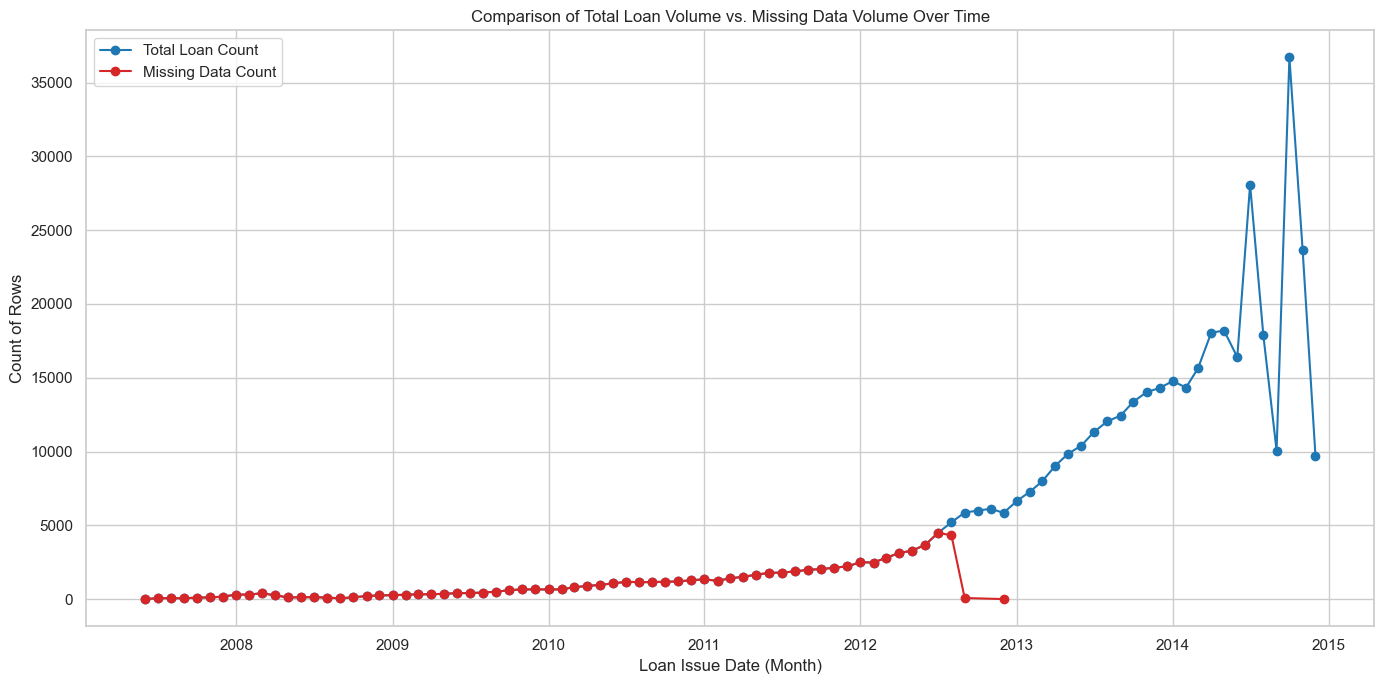

In [97]:
# Group the entire dataset by issue month and count the number of rows (loans)
total_volume_by_month = loan_df_clean.groupby(
    loan_df_clean['issue_d'].dt.to_period('M')
).size()
total_volume_by_month.index = total_volume_by_month.index.to_timestamp()


#  Calculate Missing Volume per Month (Reuse from previous steps) 
missing_by_month = rows_with_all_missing.groupby(
    rows_with_all_missing['issue_d'].dt.to_period('M')
).size()
missing_by_month.index = missing_by_month.index.to_timestamp()


#  Plot Both Time Series on the Same Graph 
plt.figure(figsize=(14, 7))

# Plot Total Volume (Blue line)
plt.plot(
    total_volume_by_month.index,
    total_volume_by_month.values,
    label='Total Loan Count',
    marker='o',
    color='tab:blue',
    linestyle='-'
)

# Plot Missing Volume (Red line)
plt.plot(
    missing_by_month.index,
    missing_by_month.values,
    label='Missing Data Count',
    marker='o',
    color='tab:red',
    linestyle='-'
)

# Labeling and Formatting
plt.title('Comparison of Total Loan Volume vs. Missing Data Volume Over Time')
plt.xlabel('Loan Issue Date (Month)')
plt.ylabel('Count of Rows')
plt.legend()
plt.tight_layout()
plt.show()

- **Insights:**
  1. It is now clear that the missing values in `total_rev_hi_lim` and `tot_cur_bal` were caused by a change in data collection. These data fields were not included in the dataset prior to 2012.
  2. To address the missing values, I will impute them with 0, indicating a lack of data collection for these variables in certain periods.
  3. The graph provides additional insights: most observations were collected later in the observation horizon, suggesting that the majority of the data reflects credit risk primarily from 2013 to 2014.


In [98]:
# Fill na
loan_df_clean[['total_rev_hi_lim', 'tot_cur_bal']] = \
    loan_df_clean[['total_rev_hi_lim', 'tot_cur_bal']].fillna(0)

---

### 5.5 Duplicated Data <a class="anchor" id="5e"></a>

In [99]:
# Check if there is duplicated data
loan_df_clean.duplicated().sum()

0

---

### 5.6 Invalid values <a class="anchor" id="5f"></a>

Invalid value are values doesn't logically make sense, such as `int_rate` < 0, `dti` < 0, `revol_util`

In [100]:
# Check descriptive statistics of interest rate
loan_df_clean['int_rate'].describe()

count   444949.0000
mean        13.8218
std          4.3603
min          5.4200
25%         10.9900
50%         13.6500
75%         16.4900
max         26.0600
Name: int_rate, dtype: float64

In [101]:
# Check descriptive statistics of debt to income ratio
loan_df_clean['dti'].describe()

count   444949.0000
mean        17.1640
std          7.8209
min          0.0000
25%         11.3300
50%         16.8100
75%         22.7000
max         39.9900
Name: dti, dtype: float64

In [102]:
# Check descriptive statistics of utilization ratio
loan_df_clean['revol_util'].describe()

count   444949.0000
mean        56.2838
std         23.7271
min          0.0000
25%         39.4000
50%         57.7000
75%         74.8000
max        892.3000
Name: revol_util, dtype: float64

All clear

---

### 4.7 Value Type Transformation <a class="anchor" id="4g"></a>

- `term`

In [103]:
# Check value counts of term column
loan_df_clean['term'].value_counts()

term
36 months    320509
60 months    124440
Name: count, dtype: int64

In [104]:
# Transform the values to int
loan_df_clean['term'] = loan_df_clean['term'].str.replace(' months', '').astype(int)

In [105]:
# Sanity check
loan_df_clean['term'].value_counts()

term
36    320509
60    124440
Name: count, dtype: int64

- `emp_length`

In [106]:
# Check value counts of term column
loan_df_clean['emp_length'].value_counts()

emp_length
10+ years    149952
2 years       41350
3 years       36573
< 1 year      36211
5 years       30756
1 year        29592
4 years       28001
7 years       26161
6 years       26094
8 years       22382
9 years       17877
Name: count, dtype: int64

In [107]:
# Remove ' years' 
loan_df_clean['emp_length'] = loan_df_clean['emp_length'].str.replace(' years', '')

# Remove ' year' 
loan_df_clean['emp_length'] = loan_df_clean['emp_length'].str.replace(' year', '')

# Replace '< 1 year' with 0
loan_df_clean['emp_length'] = loan_df_clean['emp_length'].replace('< 1', '0')

# Replace '10+ ' with 10
loan_df_clean['emp_length'] = loan_df_clean['emp_length'].replace('10+', '10')

# Convert to integer
loan_df_clean['emp_length'] = loan_df_clean['emp_length'].astype(int)

In [108]:
# Sanity check
loan_df_clean['emp_length'].value_counts()

emp_length
10    149952
2      41350
3      36573
0      36211
5      30756
1      29592
4      28001
7      26161
6      26094
8      22382
9      17877
Name: count, dtype: int64

---

### 4.8 Target Variable Creation <a class="anchor" id="4h"></a>

In this step, I will create the target variables for predicting PD LGD EAD.

In [109]:
# Get the value counts of original loan_status column
loan_df_clean['loan_status'].value_counts(normalize=True)

loan_status
Current                                               0.4775
Fully Paid                                            0.4006
Charged Off                                           0.0901
Late (31-120 days)                                    0.0146
In Grace Period                                       0.0068
Does not meet the credit policy. Status:Fully Paid    0.0043
Late (16-30 days)                                     0.0026
Default                                               0.0018
Does not meet the credit policy. Status:Charged Off   0.0017
Name: proportion, dtype: float64

As the `loan_status` 'Current' means the loan is ongoing, we cannot know the outcome of such observations, classifying them either into Default or Fully Paid category will introduce bias in the analysis and predicitons, I will therefore drop the data with Current loan status.

In [110]:
# Drop observations where loan_status is 'Current'
loan_df_clean =loan_df_clean[loan_df_clean['loan_status'] != 'Current']

- PD (default loan/total loan)

In [111]:
# Create is_default columns
loan_df_clean['is_default'] = np.where(loan_df_clean['loan_status'].isin(['Charged Off', 
                                                             'Late (31-120 days)',
                                                             'Does not meet the credit policy. Status:Charged Off', 
                                                             'Default']), 1, 0)

# Sanity Check
loan_df_clean['is_default'].value_counts(normalize=True)

is_default
0   0.7930
1   0.2070
Name: proportion, dtype: float64

- EAD

In [112]:
# Create EAD, OBLY FOR DEFAULT LOANS
loan_df_clean['exposure_at_default'] = np.where(
    loan_df_clean['is_default'] == 1,
    loan_df_clean['funded_amnt'] - loan_df_clean['total_rec_prncp'],
    0
)

loan_df_clean['exposure_at_default'].describe()

count   232506.0000
mean      2266.0352
std       5577.7977
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max      35000.0000
Name: exposure_at_default, dtype: float64

- LGD
$$\text{LGD} = 1 - \text{Recovery Rate} = 1 - \frac{\text{Recoveries} - \text{Recovery Fee}}{\text{EAD}}$$

In [113]:
# Calcualte LGD, OBLY FOR DEFAULT LOANS
loan_df_clean['loss_given_default'] = np.where(
    loan_df_clean['is_default'] == 1,
    1 - ((loan_df_clean['recoveries'] - loan_df_clean['collection_recovery_fee']) / loan_df_clean['exposure_at_default']),
    0
)

loan_df_clean['loss_given_default'].describe()

count   232504.0000
mean         0.1939
std          0.3820
min         -0.3637
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: loss_given_default, dtype: float64

By definition, Loss Given Default (LGD) is bounded within the range of [0, 1]. However, empirical observation shows that negative LGD values are possible when recoveries (e.g., from collateral liquidation) exceed the outstanding defaulted exposure. To maintain consistency with industry modeling practices used by banks, we must censor the calculated LGD values to enforce the [0, 1] bound, but first, we will examine the data for instances where LGD < 0

In [114]:
# Check missing values in LGD
loan_df_clean[loan_df_clean['loss_given_default'].isna()]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
378512,28425,28425,60,18.2400,725.5300,D,D5,3,MORTGAGE,62000.0000,Source Verified,2014-08-01,Late (31-120 days),credit_card,FL,23.1900,0.0000,0.0000,71.0000,21.0000,0.0000,28825,52.9000,49.0000,f,0.0000,34045.3982,28425.0000,5620.4000,0.0000,0.0000,0.0000,24613.5100,132494.0000,54500.0000,1,0.0000,NaN
455073,8000,8000,36,13.6600,272.1100,C,C3,10,RENT,60000.0000,Source Verified,2014-11-01,Default,debt_consolidation,CA,30.9500,0.0000,0.0000,NaN,10.0000,0.0000,40054,90.8000,26.0000,f,0.0000,8587.2894,8000.0000,587.2900,0.0000,0.0000,0.0000,6960.7000,60066.0000,44100.0000,1,0.0000,NaN


In [115]:
# fill na with 0 due to 0 EAD
loan_df_clean['loss_given_default'] = loan_df_clean['loss_given_default'].fillna(0)

In [116]:
# Get the observations with negative LGD
neg_lgd = loan_df_clean[loan_df_clean['loss_given_default'] < 0]

print(f"Number of negative observations with negative LGD: {neg_lgd.shape[0]}")

# Check the data with LGD under 0
neg_lgd.sample(5)

Number of negative observations with negative LGD: 32


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
47648,4600,4600,36,7.9000,143.9400,A,A4,1,RENT,20000.0000,Source Verified,2012-02-01,Charged Off,credit_card,LA,6.8400,0.0000,1.0000,NaN,4.0000,0.0000,1589,51.3000,27.0000,f,0.0000,5686.3800,2543.9400,470.8200,0.0000,2671.6200,464.7552,143.9400,0.0000,0.0000,1,2056.0600,-0.0733
93174,1500,1500,36,16.2900,52.9600,C,C4,5,RENT,60000.0000,Not Verified,2012-12-01,Charged Off,medical,CA,7.4200,0.0000,1.0000,NaN,8.0000,0.0000,1484,68.7000,14.0000,w,0.0000,1622.0400,65.4800,40.1800,0.0000,1516.3800,0.7000,52.9600,50985.0000,2159.0000,1,1434.5200,-0.0566
67984,3000,3000,36,20.4900,112.2500,E,E1,10,RENT,75000.0000,Not Verified,2012-08-01,Charged Off,debt_consolidation,CA,0.7000,0.0000,1.0000,49.0000,2.0000,0.0000,937,85.2000,4.0000,f,0.0000,3051.2300,60.8500,51.0700,0.0000,2939.3100,0.0000,112.2500,0.0000,0.0000,1,2939.1500,-0.0001
134231,28000,28000,60,17.2700,699.9500,C,C5,7,MORTGAGE,105000.0000,Verified,2013-05-01,Charged Off,debt_consolidation,CA,13.0500,0.0000,1.0000,NaN,15.0000,0.0000,101749,43.9000,25.0000,f,0.0000,31829.7600,3168.2000,3827.8800,0.0000,24833.6800,0.0000,699.9500,264854.0000,135100.0000,1,24831.8000,-0.0001
93774,5700,5700,36,14.0900,195.0700,B,B5,10,NONE,51500.0000,Verified,2012-12-01,Charged Off,credit_card,TX,32.4600,1.0000,3.0000,22.0000,13.0000,0.0000,11582,34.2000,17.0000,f,0.0000,8057.5500,1204.9300,544.8500,0.0000,6307.7700,1072.3209,195.0700,210446.0000,33900.0000,1,4495.0700,-0.1647


In [117]:
# Bound negative LGD to 0
loan_df_clean['loss_given_default'] = np.where(loan_df_clean['loss_given_default'] < 0, 0 , loan_df_clean['loss_given_default'])

In [118]:
loan_df_clean['loss_given_default'].describe()

count   232506.0000
mean         0.1939
std          0.3820
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: loss_given_default, dtype: float64

---

## 5. Summary and Export <a class="anchor" id="1"></a>

| Step | Description | Details |
|-------|--------------|---------|
| 1     | Convert `issue_d` to date format and order observations chronologically | Ensures temporal sequence for analysis and modeling |
| 2     | Filter out 17 irrelevant, redundant, low-variance, leaky, or high-cardinality columns | Reduces noise and potential overfitting |
| 3     | Remove variables with over 70% missing values | Improves data quality and model robustness |
| 4     | Address missing values in `mths_since_last_delinq` | To be handled after exploratory data analysis (EDA) |
| 5     | Impute missing values in `total_rev_hi_lim`, `tot_cur_bal`, `tot_coll_amt` with 0 | Due to data not being collected before 2013 |
| 6     | Confirm no duplicated or invalid data | Data integrity maintained |
| 7     | Transform duration values (e.g., '36 months' to 36) to integers | Facilitates numerical analysis and modeling |
| 8     | Create target variables (`is_default`, `exposure_at_default`, `loss_given_default`) | For predictive modeling tasks |

In [119]:
# Check the shape 
loan_df_clean.shape

(232506, 38)

In [120]:
# Export the Data
loan_df_clean.to_csv("../data/loan_clean.csv")